In [1]:
import pandas as pd
import polars as pl
import duckdb
import matplotlib.pyplot as plt

print("done")

done


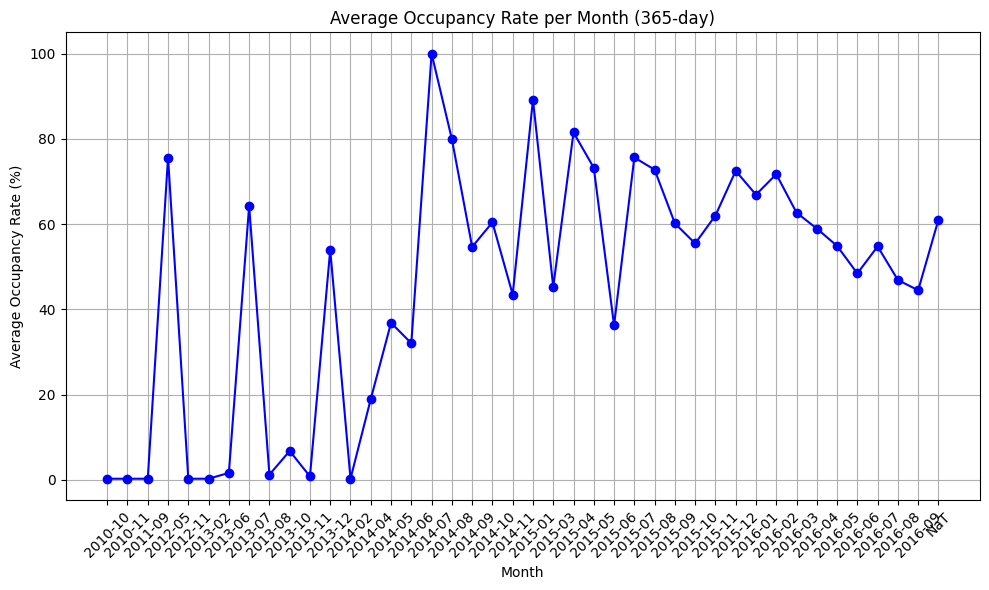

In [2]:

# load data
df = pd.read_csv("AirBnb_data_case-study/Best_Property/listings_clean.csv")

# pastikan kolom tanggal jadi datetime
df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")

# ambil bulan dari last_review
df["month"] = df["last_review"].dt.to_period("M").astype(str)

# hitung rata-rata occupancy (contoh occ_rate_30)
avg_occ = df.groupby("month")["occupancy_rate_365 (%)"].mean().reset_index()

# plot line chart
plt.figure(figsize=(10,6))
plt.plot(avg_occ["month"], avg_occ["occupancy_rate_365 (%)"], marker="o", linestyle="-", color="blue")

plt.xticks(rotation=45)  # biar label bulan kebaca
plt.xlabel("Month")
plt.ylabel("Average Occupancy Rate (%)")
plt.title("Average Occupancy Rate per Month (365-day)")
plt.grid(True)
plt.tight_layout()
plt.show()


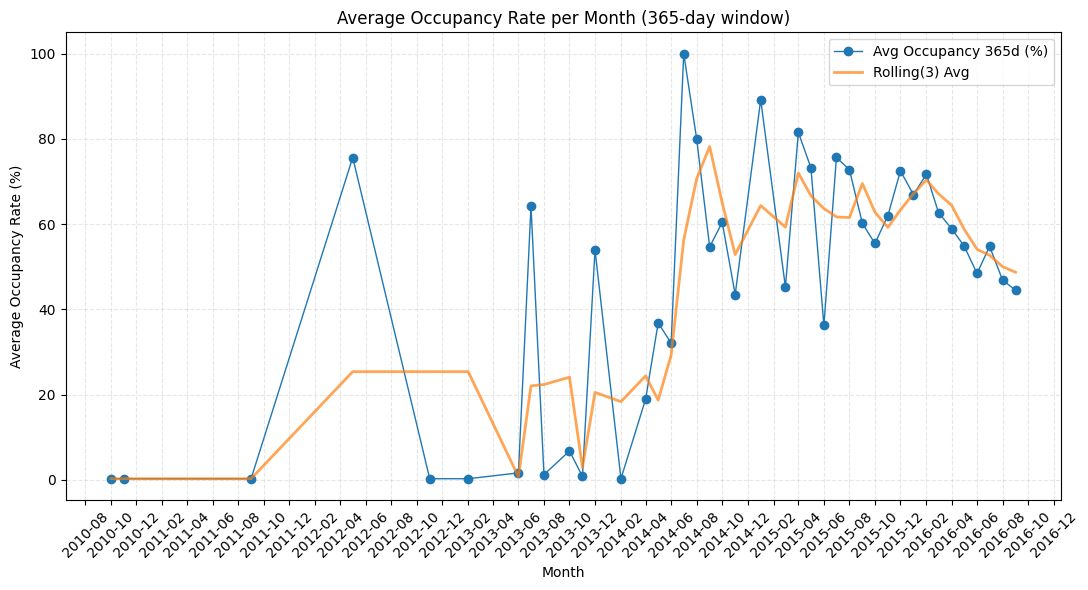

In [3]:
import matplotlib.dates as mdates

# pastikan last_review datetime
df["last_review"] = pd.to_datetime(df.get("last_review"), errors="coerce")

# buang baris yang nggak punya tanggal atau rate
df = df[df["last_review"].notna() & df["occupancy_rate_365 (%)"].notna()]

# ambil bulan dari last_review
df["month"] = df["last_review"].dt.to_period("M").dt.to_timestamp()

# hitung rata-rata occupancy per bulan
monthly = (
    df.groupby("month")["occupancy_rate_365 (%)"]
      .mean()
      .reset_index()
      .sort_values("month")
)

# (opsional) smoothing rolling 3 bulan biar garis lebih halus
monthly["smooth"] = monthly["occupancy_rate_365 (%)"].rolling(3, min_periods=1).mean()

# plot
fig, ax = plt.subplots(figsize=(11,6))
ax.plot(monthly["month"], monthly["occupancy_rate_365 (%)"], marker="o", linewidth=1, label="Avg Occupancy 365d (%)")
ax.plot(monthly["month"], monthly["smooth"], linewidth=2, label="Rolling(3) Avg", alpha=0.7)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))   # label tiap 2 bulan
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

ax.set_xlabel("Month")
ax.set_ylabel("Average Occupancy Rate (%)")
ax.set_title("Average Occupancy Rate per Month (365-day window)")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

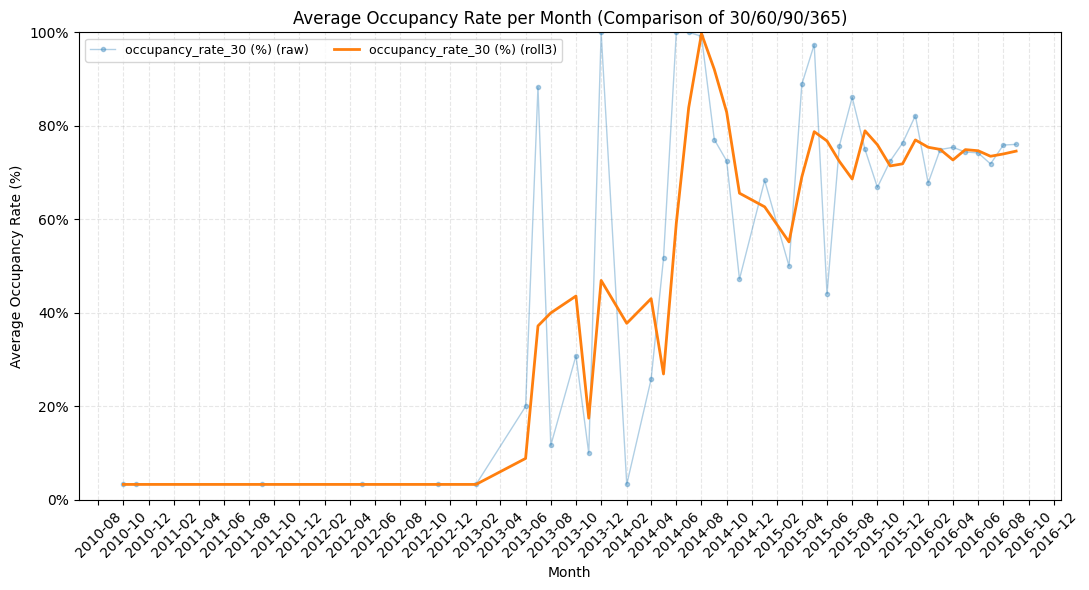

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter

# pastikan kolom tanggal ada; pakai last_review (ganti jika kamu pakai tanggal lain)
df["last_review"] = pd.to_datetime(df.get("last_review"), errors="coerce")
df = df[df["last_review"].notna()].copy()

# ambil bulan sebagai timestamp (bukan string, supaya urut rapi)
df["month"] = df["last_review"].dt.to_period("M").dt.to_timestamp()

# daftar kolom occupancy yang mau dibandingkan (sesuai namamu)
occ_cols = [
    "occupancy_rate_30 (%)",
]
# keep hanya kolom yang benar2 ada
occ_cols = [c for c in occ_cols if c in df.columns]

# ==== AGGREGASI BULANAN (RATA-RATA) ====
monthly = (
    df.groupby("month")[occ_cols]
      .mean()
      .reset_index()
      .sort_values("month")
)

# (opsional) buang bulan dgn sampel sangat sedikit biar gak “loncat”
# contoh jika kamu punya kolom 'id' utk hitung n per bulan:
# n_per_month = df.groupby("month")["id"].count()
# monthly = monthly.merge(n_per_month.rename("n"), on="month")
# monthly = monthly[monthly["n"] >= 10].drop(columns="n")

# (opsional) smoothing 3-bulan
smooth = monthly.copy()
for c in occ_cols:
    smooth[c] = smooth[c].rolling(3, min_periods=1).mean()

# ==== PLOT MULTI-LINE ====
fig, ax = plt.subplots(figsize=(11, 6))

# garis tipis = nilai asli; garis tebal = rolling(3)
for c in occ_cols:
    ax.plot(monthly["month"], monthly[c], alpha=0.35, linewidth=1, marker="o", markersize=3, label=f"{c} (raw)")
for c in occ_cols:
    ax.plot(smooth["month"], smooth[c], linewidth=2, label=f"{c} (roll3)")

# format sumbu X sebagai bulan
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

# format Y jadi persen
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.set_ylim(0, 100)  # occupancy rate dalam %, sesuaikan jika perlu

ax.set_xlabel("Month")
ax.set_ylabel("Average Occupancy Rate (%)")
ax.set_title("Average Occupancy Rate per Month (Comparison of 30/60/90/365)")

ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


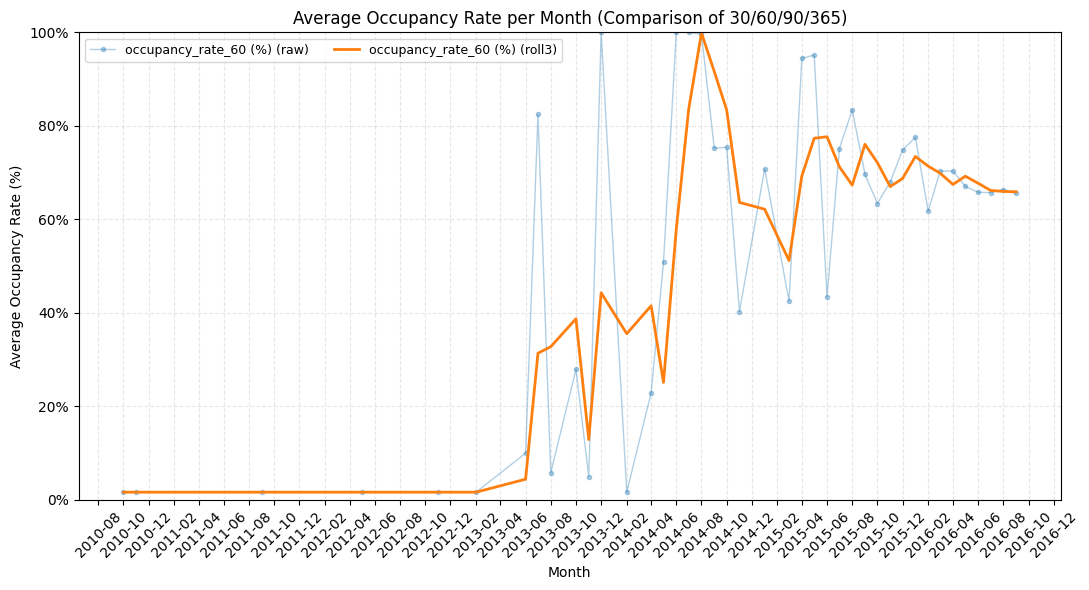

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter

# pastikan kolom tanggal ada; pakai last_review (ganti jika kamu pakai tanggal lain)
df["last_review"] = pd.to_datetime(df.get("last_review"), errors="coerce")
df = df[df["last_review"].notna()].copy()

# ambil bulan sebagai timestamp (bukan string, supaya urut rapi)
df["month"] = df["last_review"].dt.to_period("M").dt.to_timestamp()

# daftar kolom occupancy yang mau dibandingkan (sesuai namamu)
occ_cols = [
    "occupancy_rate_60 (%)",
]
# keep hanya kolom yang benar2 ada
occ_cols = [c for c in occ_cols if c in df.columns]

# ==== AGGREGASI BULANAN (RATA-RATA) ====
monthly = (
    df.groupby("month")[occ_cols]
      .mean()
      .reset_index()
      .sort_values("month")
)

# (opsional) buang bulan dgn sampel sangat sedikit biar gak “loncat”
# contoh jika kamu punya kolom 'id' utk hitung n per bulan:
# n_per_month = df.groupby("month")["id"].count()
# monthly = monthly.merge(n_per_month.rename("n"), on="month")
# monthly = monthly[monthly["n"] >= 10].drop(columns="n")

# (opsional) smoothing 3-bulan
smooth = monthly.copy()
for c in occ_cols:
    smooth[c] = smooth[c].rolling(3, min_periods=1).mean()

# ==== PLOT MULTI-LINE ====
fig, ax = plt.subplots(figsize=(11, 6))

# garis tipis = nilai asli; garis tebal = rolling(3)
for c in occ_cols:
    ax.plot(monthly["month"], monthly[c], alpha=0.35, linewidth=1, marker="o", markersize=3, label=f"{c} (raw)")
for c in occ_cols:
    ax.plot(smooth["month"], smooth[c], linewidth=2, label=f"{c} (roll3)")

# format sumbu X sebagai bulan
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

# format Y jadi persen
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.set_ylim(0, 100)  # occupancy rate dalam %, sesuaikan jika perlu

ax.set_xlabel("Month")
ax.set_ylabel("Average Occupancy Rate (%)")
ax.set_title("Average Occupancy Rate per Month (Comparison of 30/60/90/365)")

ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


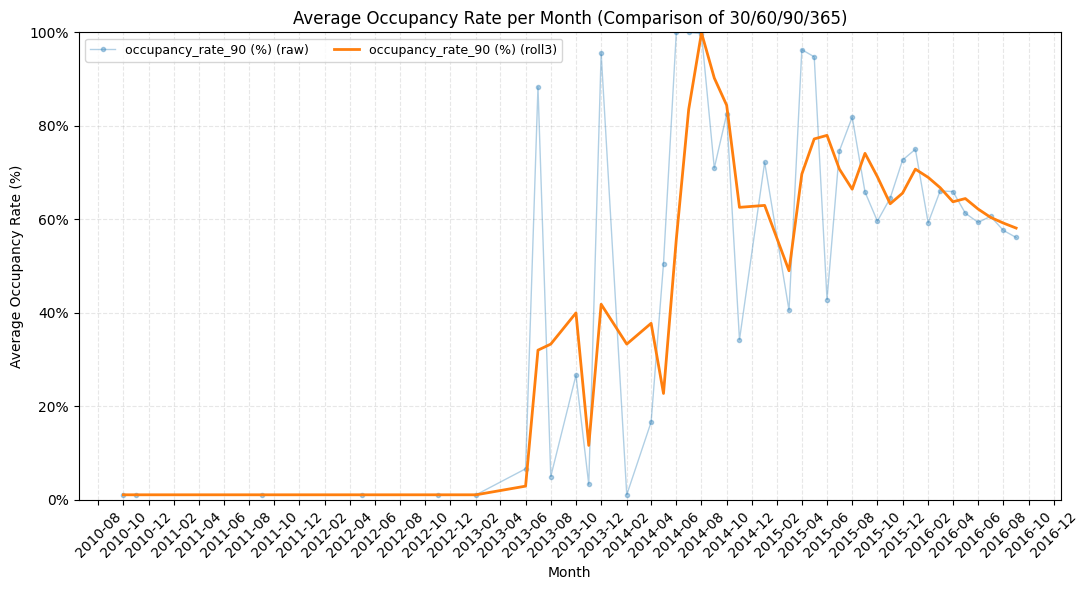

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter

# pastikan kolom tanggal ada; pakai last_review (ganti jika kamu pakai tanggal lain)
df["last_review"] = pd.to_datetime(df.get("last_review"), errors="coerce")
df = df[df["last_review"].notna()].copy()

# ambil bulan sebagai timestamp (bukan string, supaya urut rapi)
df["month"] = df["last_review"].dt.to_period("M").dt.to_timestamp()

# daftar kolom occupancy yang mau dibandingkan (sesuai namamu)
occ_cols = [
    "occupancy_rate_90 (%)",
]
# keep hanya kolom yang benar2 ada
occ_cols = [c for c in occ_cols if c in df.columns]

# ==== AGGREGASI BULANAN (RATA-RATA) ====
monthly = (
    df.groupby("month")[occ_cols]
      .mean()
      .reset_index()
      .sort_values("month")
)

# (opsional) buang bulan dgn sampel sangat sedikit biar gak “loncat”
# contoh jika kamu punya kolom 'id' utk hitung n per bulan:
# n_per_month = df.groupby("month")["id"].count()
# monthly = monthly.merge(n_per_month.rename("n"), on="month")
# monthly = monthly[monthly["n"] >= 10].drop(columns="n")

# (opsional) smoothing 3-bulan
smooth = monthly.copy()
for c in occ_cols:
    smooth[c] = smooth[c].rolling(3, min_periods=1).mean()

# ==== PLOT MULTI-LINE ====
fig, ax = plt.subplots(figsize=(11, 6))

# garis tipis = nilai asli; garis tebal = rolling(3)
for c in occ_cols:
    ax.plot(monthly["month"], monthly[c], alpha=0.35, linewidth=1, marker="o", markersize=3, label=f"{c} (raw)")
for c in occ_cols:
    ax.plot(smooth["month"], smooth[c], linewidth=2, label=f"{c} (roll3)")

# format sumbu X sebagai bulan
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

# format Y jadi persen
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.set_ylim(0, 100)  # occupancy rate dalam %, sesuaikan jika perlu

ax.set_xlabel("Month")
ax.set_ylabel("Average Occupancy Rate (%)")
ax.set_title("Average Occupancy Rate per Month (Comparison of 30/60/90/365)")

ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


In [7]:
# hitung rata-rata occupancy per bulan (misalnya pakai occ_rate_30)
monthly = (
    df.groupby("month")["occupancy_rate_30 (%)"]
      .mean()
      .reset_index()
      .sort_values("month")
)

# cari bulan dengan occupancy tertinggi
peak = monthly.loc[monthly["occupancy_rate_30 (%)"].idxmax()]
print("Peak season:", peak["month"], "dengan rata-rata occupancy:", peak["occupancy_rate_30 (%)"])


Peak season: 2013-12-01 00:00:00 dengan rata-rata occupancy: 100.0


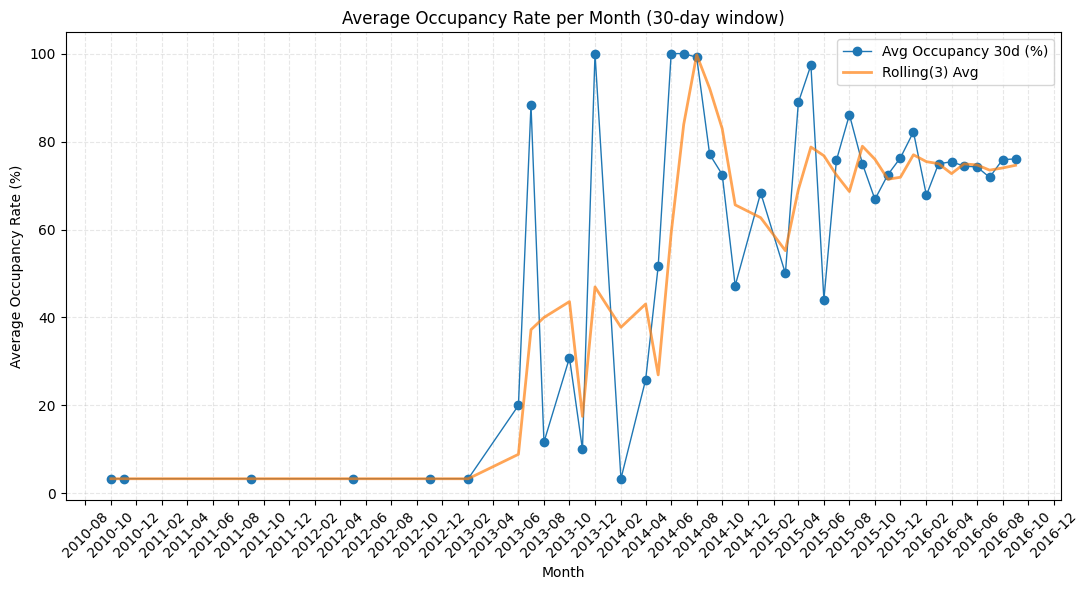

In [8]:
# pastikan datetime
df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")

# filter hanya tahun 2016
df_2016 = df[df["last_review"].dt.year == 2016]
# df_range = df[
#    (df["last_review"].dt.year >= 2015) &
#    (df["last_review"].dt.year <= 2016)
#]

# hitung rata-rata occupancy per bulan
monthly = (
    df.groupby("month")["occupancy_rate_30 (%)"]
      .mean()
      .reset_index()
      .sort_values("month")
)


# (opsional) smoothing rolling 3 bulan biar garis lebih halus
monthly["smooth"] = monthly["occupancy_rate_30 (%)"].rolling(3, min_periods=1).mean()

# plot
fig, ax = plt.subplots(figsize=(11,6))
ax.plot(monthly["month"], monthly["occupancy_rate_30 (%)"], marker="o", linewidth=1, label="Avg Occupancy 30d (%)")
ax.plot(monthly["month"], monthly["smooth"], linewidth=2, label="Rolling(3) Avg", alpha=0.7)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))   # label tiap 2 bulan
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

ax.set_xlabel("Month")
ax.set_ylabel("Average Occupancy Rate (%)")
ax.set_title("Average Occupancy Rate per Month (30-day window)")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

C:\Users\tiara\AppData\Local\Temp\ipykernel_21012\1096306106.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")


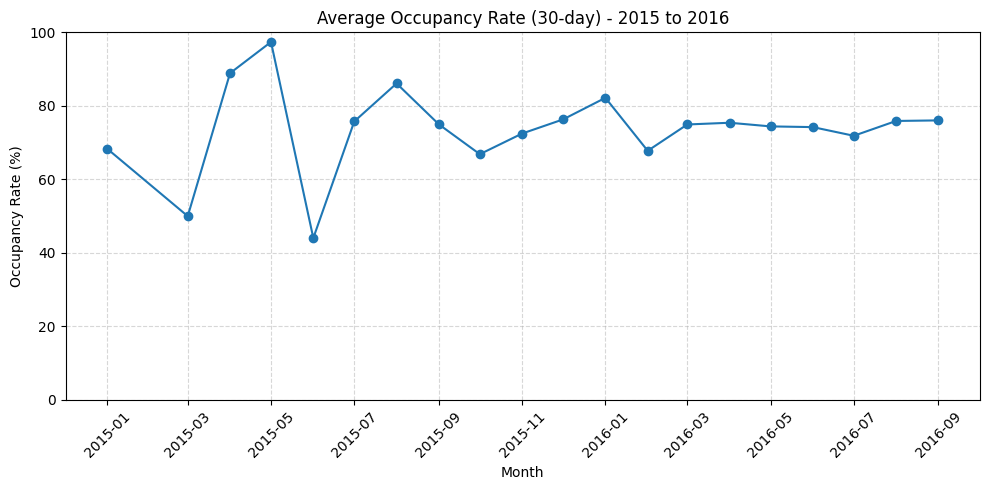

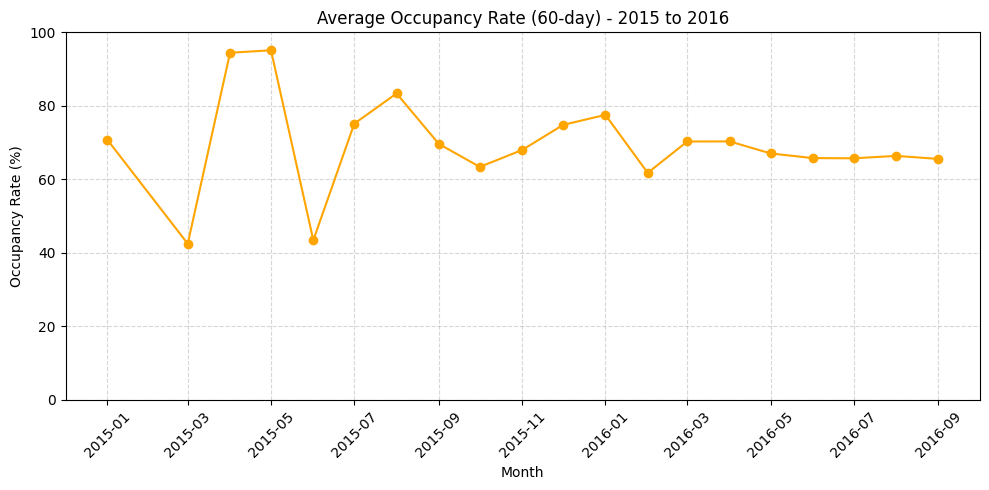

In [11]:
# Ubah kolom last_review jadi datetime
df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")

# Filter hanya tahun 2015-2016
df = df[(df["last_review"].dt.year >= 2015) & (df["last_review"].dt.year <= 2016)]

# Buat kolom "month" untuk agregasi per bulan
df["month"] = df["last_review"].dt.to_period("M").dt.to_timestamp()

# Hitung rata-rata bulanan occupancy rate 30d dan 60d
monthly_30 = df.groupby("month")["occupancy_rate_30 (%)"].mean()
monthly_60 = df.groupby("month")["occupancy_rate_60 (%)"].mean()

# ================= Grafik 1: 30-day =================
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(monthly_30.index, monthly_30.values, marker="o", linestyle="-", label="30-day occupancy")

# Format axis
ax.set_title("Average Occupancy Rate (30-day) - 2015 to 2016")
ax.set_ylabel("Occupancy Rate (%)")
ax.set_xlabel("Month")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
ax.set_ylim(0, 100)

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ================= Grafik 2: 60-day =================
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(monthly_60.index, monthly_60.values, marker="o", linestyle="-", color="orange", label="60-day occupancy")

# Format axis
ax.set_title("Average Occupancy Rate (60-day) - 2015 to 2016")
ax.set_ylabel("Occupancy Rate (%)")
ax.set_xlabel("Month")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
ax.set_ylim(0, 100)

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# RENTAL RATE SHOULD STAY AVERAGE